In [5]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", DEVICE)
ROOT = Path("data")

OUTPUT_DIR = Path("calibration_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

Using: cuda


In [23]:
def normalize_binary_series(series: pd.Series) -> pd.Series:
    """
    Convert TRUE/FALSE, True/False, 1/0, yes/no-like columns into 0/1 integers.
    """
    if pd.api.types.is_bool_dtype(series):
        return series.astype(int)

    if pd.api.types.is_numeric_dtype(series):
        return series.fillna(0).astype(int)

    s = series.astype(str).str.strip().str.upper()
    mapping = {
        "TRUE": 1,
        "FALSE": 0,
        "1": 1,
        "0": 0,
        "YES": 1,
        "NO": 0,
        "T": 1,
        "F": 0,
    }
    out = s.map(mapping)

    if out.isna().any():
        raise ValueError(
            f"Could not normalize binary column values in {series.name}. "
            "Check the labels.csv file."
        )
    return out.astype(int)


class CarlaBinaryDataset(Dataset):
    def __init__(self, root_dir, target_column, transform=None):
        self.root_dir = Path(root_dir)
        self.target_column = target_column
        self.transform = transform

        labels_path = self.root_dir / "labels.csv"
        if not labels_path.exists():
            raise FileNotFoundError(f"Missing {labels_path}")

        df = pd.read_csv(labels_path)
        df.columns = df.columns.str.strip()

        if "frame" not in df.columns:
            raise KeyError("labels.csv must contain a 'frame' column.")
        if target_column not in df.columns:
            raise KeyError(f"labels.csv does not contain target column '{target_column}'.")

        df["frame"] = df["frame"].astype(int)
        df[target_column] = normalize_binary_series(df[target_column])

        self.image_dir = self.root_dir / "rgb-front"

        valid_rows = []
        for _, row in df.iterrows():
            image_path = self.image_dir / f"{int(row['frame']):06d}.jpg"
            if image_path.exists():
                valid_rows.append(row)

        self.df = pd.DataFrame(valid_rows).reset_index(drop=True)

        print(f"{root_dir}: {len(self.df)} valid images for target='{target_column}'")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = self.image_dir / f"{int(row['frame']):06d}.jpg"

        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        label = torch.tensor(float(row[self.target_column]), dtype=torch.float32)
        return image, label

In [24]:
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

def build_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model

def load_model(model_path):
    model = build_model()
    state_dict = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    model = model.to(DEVICE)
    model.eval()
    return model

def make_loader(root_dir, target_column, batch_size=64, shuffle=False):
    dataset = CarlaBinaryDataset(root_dir, target_column, transform=eval_transform)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0)

def collect_logits_and_labels(model, loader):
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            logits = model(images).squeeze(1)  # shape: [batch]
            all_logits.append(logits.cpu())
            all_labels.append(labels.cpu())

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy().astype(int)
    return logits, labels

def sigmoid_np(x):
    x = np.clip(x, -80, 80)
    return 1.0 / (1.0 + np.exp(-x))

def predicted_class_confidence(probs):
    """
    For calibration we use the confidence of the predicted class:
    - if p >= 0.5, confidence = p
    - if p < 0.5, confidence = 1-p
    """
    preds = (probs >= 0.5).astype(int)
    conf = np.where(preds == 1, probs, 1.0 - probs)
    return preds, conf

def calibration_stats(logits, labels, temperature=1.0, n_bins=10):
    """
    Compute calibration statistics using predicted-class confidence.

    Returns:
        ece
        signed_gap
        predicted probabilities
        predicted labels
        confidence
        correctness
        per-bin confidence
        per-bin accuracy
        per-bin sample counts
    """

    # Apply temperature scaling
    probs = sigmoid_np(logits / temperature)

    # Binary predictions
    preds = (probs >= 0.5).astype(int)

    # Confidence of the predicted class
    conf = np.where(preds == 1, probs, 1.0 - probs)

    # Correct / incorrect prediction
    correct = (preds == labels).astype(int)

    # Confidence bins
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    bin_acc = []
    bin_conf = []
    bin_counts = []

    ece = 0.0
    signed_gap = 0.0

    for i in range(n_bins):

        lo = bin_edges[i]
        hi = bin_edges[i + 1]

        if i == n_bins - 1:
            mask = (conf >= lo) & (conf <= hi)
        else:
            mask = (conf >= lo) & (conf < hi)

        count = int(mask.sum())
        bin_counts.append(count)

        if count == 0:
            bin_acc.append(np.nan)
            bin_conf.append(np.nan)
            continue

        acc = correct[mask].mean()
        avg_conf = conf[mask].mean()

        bin_acc.append(acc)
        bin_conf.append(avg_conf)

        weight = count / len(labels)

        # Expected Calibration Error
        ece += weight * abs(acc - avg_conf)

        # Signed calibration gap
        signed_gap += weight * (avg_conf - acc)

    return {
        "ece": float(ece),
        "signed_gap": float(signed_gap),
        "probs": probs,
        "preds": preds,
        "conf": conf,
        "correct": correct,
        "bin_acc": np.array(bin_acc),
        "bin_conf": np.array(bin_conf),
        "bin_counts": np.array(bin_counts)
    }

def plot_reliability_diagram(stats, title, save_path=None):
    n_bins = len(stats["bin_acc"])
    centers = np.linspace(0.05, 0.95, n_bins)
    bar_width = 0.08

    plt.figure(figsize=(6.5, 6))
    plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

    # Only plot non-empty bins
    mask = ~np.isnan(stats["bin_acc"])
    plt.bar(centers[mask], stats["bin_acc"][mask], width=bar_width, alpha=0.7, label="Bin accuracy")
    plt.scatter(centers[mask], stats["bin_conf"][mask], s=35, label="Bin mean confidence")

    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

In [25]:
# Update these paths if your model files have different names.
# If a file does not exist, it will be skipped automatically.

MODEL_SPECS = [

    {
        "name": "Pedestrian",
        "model_path": "pedestrian_model.pth",
        "target_column": "has_pedestrian",
    },

    {
        "name": "Vehicle",
        "model_path": "vehicle_model.pth",
        "target_column": "has_vehicle",
    },

    {
        "name": "Traffic Light",
        "model_path": "traffic_light_model.pth",
        "target_column": "has_traffic_light",
    }

]

MODEL_SPECS = [m for m in MODEL_SPECS if Path(m["model_path"]).exists()]

if len(MODEL_SPECS) == 0:
    raise FileNotFoundError(
        "No model files found. Put best_model.pth or the 3 model files in the data/ folder."
    )

print("Models found:", [m["name"] for m in MODEL_SPECS])

Models found: ['Pedestrian', 'Vehicle', 'Traffic Light']


In [26]:
print("=" * 60)
print(spec["name"])
print("Target column:", spec["target_column"])
print("Model file:", spec["model_path"])
print("=" * 60)

print("Logit min :", logits_test.min())
print("Logit max :", logits_test.max())
print("Logit mean:", logits_test.mean())

probs = sigmoid_np(logits_test)

print("\nProbability min :", probs.min())
print("Probability max :", probs.max())
print("Probability mean:", probs.mean())

Traffic Light
Target column: has_traffic_light
Model file: traffic_light_model.pth
Logit min : -5.1167603
Logit max : 4.3519397
Logit mean: -2.391685

Probability min : 0.0059596845
Probability max : 0.9872821
Probability mean: 0.1121993


In [27]:
import pandas as pd

for spec in MODEL_SPECS:

    df = pd.read_csv(f"data/test/labels.csv")

    print("\n")
    print(spec["name"])

    print(
        df[spec["target_column"]].value_counts()
    )



Pedestrian
has_pedestrian
False    2894
True      706
Name: count, dtype: int64


Vehicle
has_vehicle
True     2700
False     900
Name: count, dtype: int64


Traffic Light
has_traffic_light
True     2584
False    1016
Name: count, dtype: int64


Compute ECE and reliability diagram for each model


Evaluating calibration for: Pedestrian
data\test: 3600 valid images for target='has_pedestrian'
ECE: 0.1555
Mean confidence (predicted class): 0.9594
Mean accuracy: 0.8039
Signed calibration gap: 0.1555
Overall pattern: OVERCONFIDENT


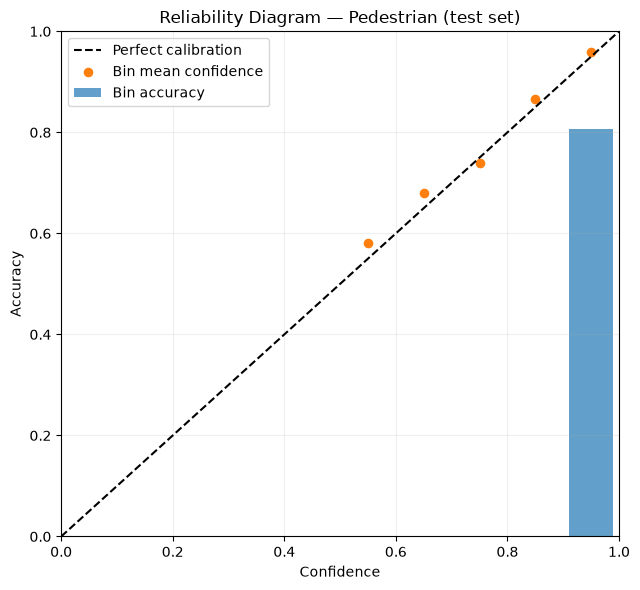


Evaluating calibration for: Vehicle
data\test: 3600 valid images for target='has_vehicle'
ECE: 0.7362
Mean confidence (predicted class): 0.9862
Mean accuracy: 0.2500
Signed calibration gap: 0.7362
Overall pattern: OVERCONFIDENT


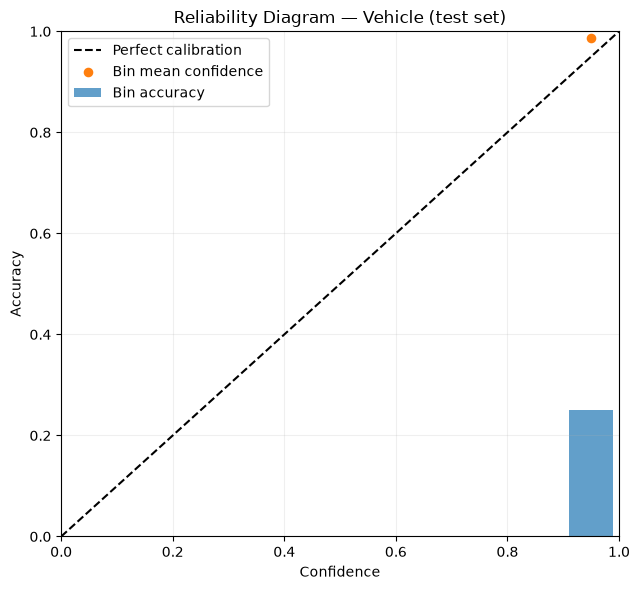


Evaluating calibration for: Traffic Light
data\test: 3600 valid images for target='has_traffic_light'
ECE: 0.5973
Mean confidence (predicted class): 0.9021
Mean accuracy: 0.3047
Signed calibration gap: 0.5973
Overall pattern: OVERCONFIDENT


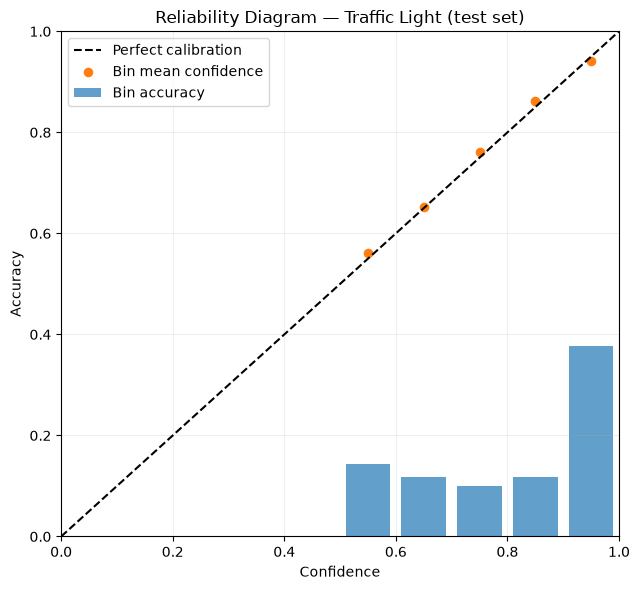


Summary (Exercise 7.4):
        model      ece  mean_confidence  mean_accuracy  signed_gap       pattern
   Pedestrian 0.155530         0.959419       0.803889    0.155530 OVERCONFIDENT
      Vehicle 0.736209         0.986209       0.250000    0.736209 OVERCONFIDENT
Traffic Light 0.597335         0.902057       0.304722    0.597335 OVERCONFIDENT


In [28]:
results_74 = []

for spec in MODEL_SPECS:
    print("\n" + "=" * 80)
    print(f"Evaluating calibration for: {spec['name']}")

    model = load_model(spec["model_path"])
    test_loader = make_loader(ROOT / "test", spec["target_column"], batch_size=64, shuffle=False)

    logits_test, labels_test = collect_logits_and_labels(model, test_loader)
    stats = calibration_stats(logits_test, labels_test, temperature=1.0, n_bins=10)

    over_under = "OVERCONFIDENT" if stats["signed_gap"] > 0 else "UNDERCONFIDENT"

    print(f"ECE: {stats['ece']:.4f}")
    print(f"Mean confidence (predicted class): {stats['conf'].mean():.4f}")
    print(f"Mean accuracy: {stats['correct'].mean():.4f}")
    print(f"Signed calibration gap: {stats['signed_gap']:.4f}")
    print(f"Overall pattern: {over_under}")

    out_path = OUTPUT_DIR / f"reliability_{spec['name']}.png"
    plot_reliability_diagram(
        stats,
        title=f"Reliability Diagram — {spec['name']} (test set)",
        save_path=out_path,
    )

    results_74.append({
        "model": spec["name"],
        "ece": stats["ece"],
        "mean_confidence": float(stats["conf"].mean()),
        "mean_accuracy": float(stats["correct"].mean()),
        "signed_gap": stats["signed_gap"],
        "pattern": over_under,
        "logits_test": logits_test,
        "labels_test": labels_test,
    })

results_74_df = pd.DataFrame(results_74).drop(columns=["logits_test", "labels_test"])
print("\nSummary (Exercise 7.4):")
print(results_74_df.to_string(index=False))

In [32]:
for spec in MODEL_SPECS:

    print("\n" + "=" * 80)
    print(spec["name"])

    model = load_model(spec["model_path"])

    loader = make_loader(
        ROOT / "test",
        spec["target_column"],
        batch_size=64,
        shuffle=False
    )

    logits, labels = collect_logits_and_labels(model, loader)

    probs = sigmoid_np(logits)
    preds = (probs >= 0.5).astype(int)

    print("Positive predictions :", preds.sum())
    print("Negative predictions :", len(preds) - preds.sum())

    print("Ground truth positives :", labels.sum())
    print("Ground truth negatives :", len(labels) - labels.sum())

    print("Accuracy :", (preds == labels).mean())

    print("Probability mean :", probs.mean())


Pedestrian
data\test: 3600 valid images for target='has_pedestrian'
Positive predictions : 0
Negative predictions : 3600
Ground truth positives : 706
Ground truth negatives : 2894
Accuracy : 0.8038888888888889
Probability mean : 0.04058109

Vehicle
data\test: 3600 valid images for target='has_vehicle'
Positive predictions : 0
Negative predictions : 3600
Ground truth positives : 2700
Ground truth negatives : 900
Accuracy : 0.25
Probability mean : 0.013791051

Traffic Light
data\test: 3600 valid images for target='has_traffic_light'
Positive predictions : 81
Negative predictions : 3519
Ground truth positives : 2584
Ground truth negatives : 1016
Accuracy : 0.3047222222222222
Probability mean : 0.1121993


In [33]:
for spec in MODEL_SPECS:

    print("="*60)
    print(spec["name"])

    model = load_model(spec["model_path"])

    loader = make_loader(
        ROOT/"test",
        spec["target_column"]
    )

    logits, labels = collect_logits_and_labels(model, loader)

    probs = sigmoid_np(logits)

    print("Minimum probability:", probs.min())
    print("Maximum probability:", probs.max())

    print("Predictions >0.5 :", (probs>0.5).sum())

Pedestrian
data\test: 3600 valid images for target='has_pedestrian'
Minimum probability: 0.0018220025
Maximum probability: 0.4359939
Predictions >0.5 : 0
Vehicle
data\test: 3600 valid images for target='has_vehicle'
Minimum probability: 0.0023281004
Maximum probability: 0.025503244
Predictions >0.5 : 0
Traffic Light
data\test: 3600 valid images for target='has_traffic_light'
Minimum probability: 0.0059596845
Maximum probability: 0.9872821
Predictions >0.5 : 81


In [29]:
import pandas as pd

print("=" * 80)
print("BIN DISTRIBUTION FOR EACH MODEL")
print("=" * 80)

for result in results_74:

    print(f"\nModel: {result['model']}")
    print("-" * 80)

    # Recompute calibration statistics to access bin information
    stats = calibration_stats(
        result["logits_test"],
        result["labels_test"],
        temperature=1.0,
        n_bins=10
    )

    bin_table = pd.DataFrame({
        "Bin": [f"{i/10:.1f}-{(i+1)/10:.1f}" for i in range(10)],
        "Samples": stats["bin_counts"],
        "Mean Confidence": [
            round(x, 4) if not pd.isna(x) else "-"
            for x in stats["bin_conf"]
        ],
        "Mean Accuracy": [
            round(x, 4) if not pd.isna(x) else "-"
            for x in stats["bin_acc"]
        ]
    })

    print(bin_table.to_string(index=False))

BIN DISTRIBUTION FOR EACH MODEL

Model: Pedestrian
--------------------------------------------------------------------------------
    Bin  Samples Mean Confidence Mean Accuracy
0.0-0.1        0               -             -
0.1-0.2        0               -             -
0.2-0.3        0               -             -
0.3-0.4        0               -             -
0.4-0.5        0               -             -
0.5-0.6        2          0.5811           0.0
0.6-0.7        1          0.6807           0.0
0.7-0.8        2          0.7395           0.0
0.8-0.9        8           0.867           0.0
0.9-1.0     3587            0.96        0.8068

Model: Vehicle
--------------------------------------------------------------------------------
    Bin  Samples Mean Confidence Mean Accuracy
0.0-0.1        0               -             -
0.1-0.2        0               -             -
0.2-0.3        0               -             -
0.3-0.4        0               -             -
0.4-0.5        0   

In [30]:
import hashlib

def md5(fname):
    with open(fname, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

print("Pedestrian :", md5("pedestrian_model.pth"))
print("Vehicle    :", md5("vehicle_model.pth"))
print("Traffic    :", md5("traffic_light_model.pth"))

Pedestrian : 219735daf94b01096f8156f0efc1ac4e
Vehicle    : b69f6dd9e8c65e8cc282351b7e5ad362
Traffic    : f0b0f926cb16ae7aa7914cfcbef2f952


In [31]:
for spec in MODEL_SPECS:

    print("\n")
    print("="*50)
    print(spec["name"])

    model = load_model(spec["model_path"])

    first_weight = next(model.parameters())

    print(first_weight.flatten()[:10])



Pedestrian
tensor([-0.0473, -0.0314, -0.0137,  0.0563,  0.0325, -0.0098, -0.0437, -0.0040,
         0.0091, -0.1129], device='cuda:0', grad_fn=<SliceBackward0>)


Vehicle
tensor([-0.0180, -0.0024,  0.0130,  0.0934,  0.0698,  0.0220, -0.0115, -0.0149,
         0.0065, -0.0990], device='cuda:0', grad_fn=<SliceBackward0>)


Traffic Light
tensor([-0.0054, -0.0005,  0.0114,  0.0923,  0.0765,  0.0326,  0.0020,  0.0105,
         0.0088, -0.1023], device='cuda:0', grad_fn=<SliceBackward0>)


Temperature scaling by grid search on validation NLL


Temperature scaling for: Pedestrian
data\validation: 3600 valid images for target='has_pedestrian'
data\test: 3600 valid images for target='has_pedestrian'
Best T on validation NLL: 2.9
Test ECE before scaling: 0.1555
Test ECE after  scaling: 0.0561


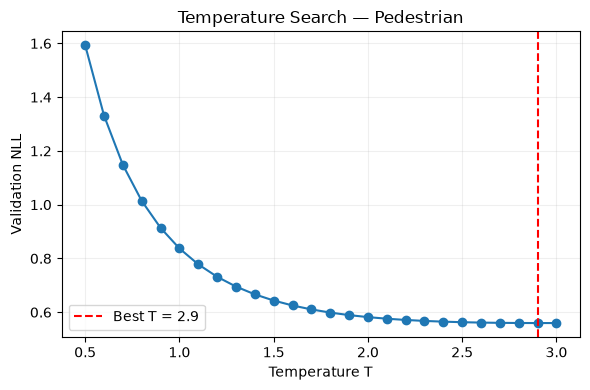

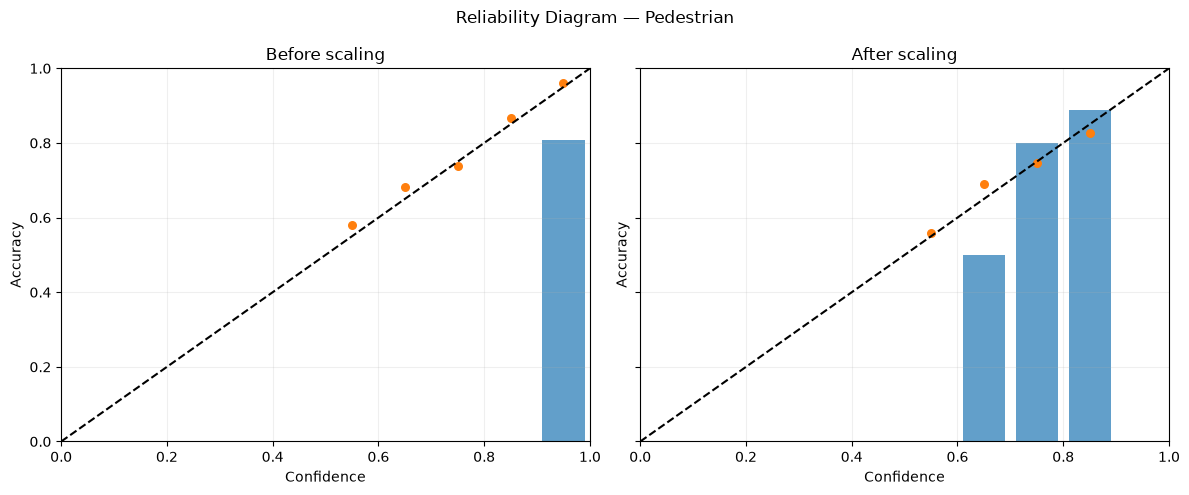


Temperature scaling for: Vehicle
data\validation: 3600 valid images for target='has_vehicle'
data\test: 3600 valid images for target='has_vehicle'
Best T on validation NLL: 3.0
Test ECE before scaling: 0.7362
Test ECE after  scaling: 0.5574


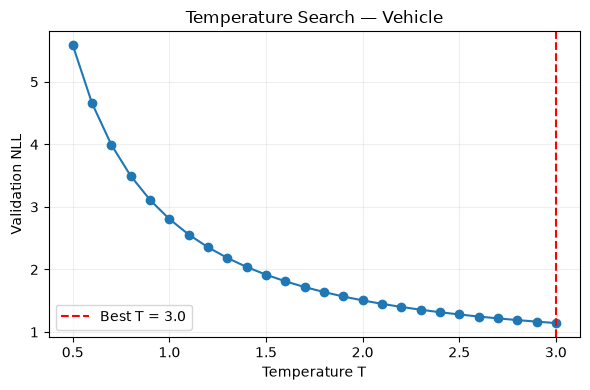

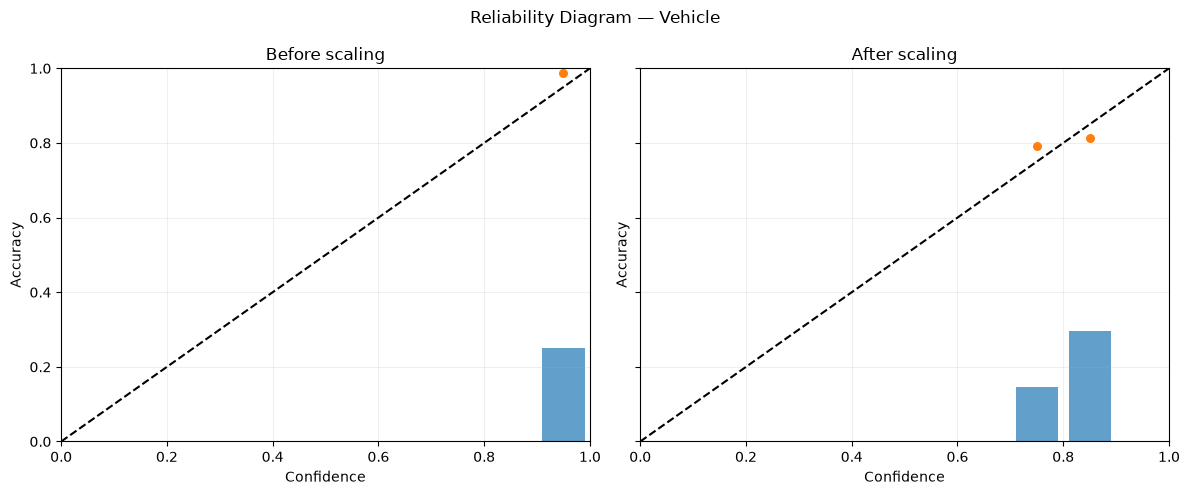


Temperature scaling for: Traffic Light
data\validation: 3600 valid images for target='has_traffic_light'
data\test: 3600 valid images for target='has_traffic_light'
Best T on validation NLL: 3.0
Test ECE before scaling: 0.5973
Test ECE after  scaling: 0.3936


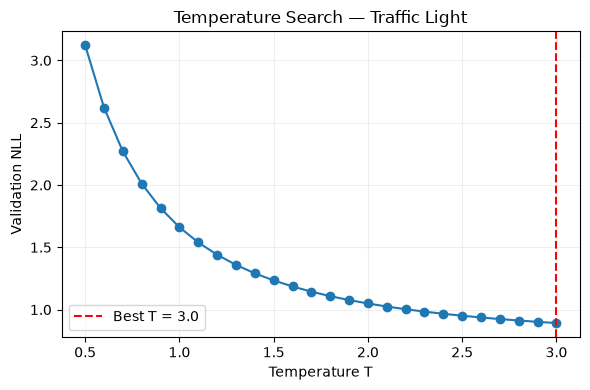

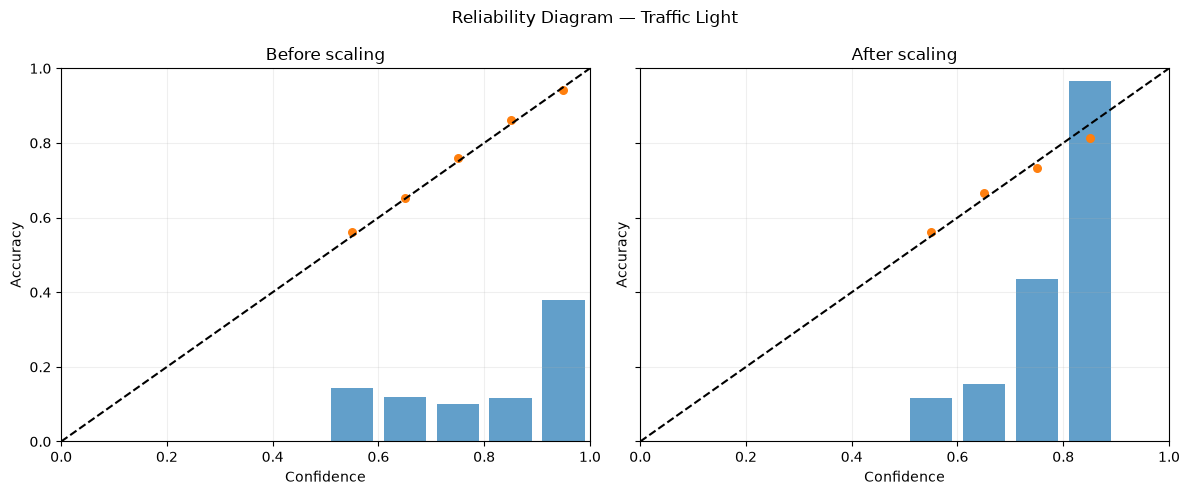


Summary (Exercise 7.5):
        model  best_T  ece_before  ece_after  signed_gap_before  signed_gap_after
   Pedestrian     2.9    0.155530   0.056149           0.155530         -0.049542
      Vehicle     3.0    0.736209   0.557361           0.736209          0.557361
Traffic Light     3.0    0.597335   0.393565           0.597335          0.388551


In [10]:
def validation_nll_for_temperature(logits, labels, temperature):
    """
    For binary classification with a single logit, temperature scaling is:
    logits / T
    """
    logits_t = torch.tensor(logits / temperature, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.float32)

    loss_fn = nn.BCEWithLogitsLoss(reduction="mean")
    loss = loss_fn(logits_t, labels_t)
    return float(loss.item())

def find_best_temperature(model, val_loader, temp_grid=None):
    if temp_grid is None:
        temp_grid = np.round(np.arange(0.5, 3.01, 0.1), 1)

    logits_val, labels_val = collect_logits_and_labels(model, val_loader)

    losses = []
    for T in temp_grid:
        nll = validation_nll_for_temperature(logits_val, labels_val, T)
        losses.append(nll)

    best_idx = int(np.argmin(losses))
    best_T = float(temp_grid[best_idx])

    return best_T, np.array(temp_grid), np.array(losses), logits_val, labels_val

results_75 = []

for spec in MODEL_SPECS:
    print("\n" + "=" * 80)
    print(f"Temperature scaling for: {spec['name']}")

    model = load_model(spec["model_path"])

    val_loader = make_loader(ROOT / "validation", spec["target_column"], batch_size=64, shuffle=False)
    test_loader = make_loader(ROOT / "test", spec["target_column"], batch_size=64, shuffle=False)

    best_T, grid, val_nlls, logits_val, labels_val = find_best_temperature(model, val_loader)

    # Test set calibration before/after scaling
    logits_test, labels_test = collect_logits_and_labels(model, test_loader)

    before = calibration_stats(logits_test, labels_test, temperature=1.0, n_bins=10)
    after = calibration_stats(logits_test, labels_test, temperature=best_T, n_bins=10)

    print(f"Best T on validation NLL: {best_T:.1f}")
    print(f"Test ECE before scaling: {before['ece']:.4f}")
    print(f"Test ECE after  scaling: {after['ece']:.4f}")

    # Plot validation NLL vs T
    plt.figure(figsize=(6, 4))
    plt.plot(grid, val_nlls, marker="o")
    plt.axvline(best_T, color="red", linestyle="--", label=f"Best T = {best_T:.1f}")
    plt.xlabel("Temperature T")
    plt.ylabel("Validation NLL")
    plt.title(f"Temperature Search — {spec['name']}")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"temperature_search_{spec['name']}.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Plot reliability diagrams before/after
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    for ax, stats, title in [
        (axes[0], before, "Before scaling"),
        (axes[1], after, "After scaling"),
    ]:
        n_bins = len(stats["bin_acc"])
        centers = np.linspace(0.05, 0.95, n_bins)
        mask = ~np.isnan(stats["bin_acc"])
        ax.plot([0, 1], [0, 1], "k--")
        ax.bar(centers[mask], stats["bin_acc"][mask], width=0.08, alpha=0.7)
        ax.scatter(centers[mask], stats["bin_conf"][mask], s=30)
        ax.set_title(title)
        ax.set_xlabel("Confidence")
        ax.set_ylabel("Accuracy")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.2)

    fig.suptitle(f"Reliability Diagram — {spec['name']}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"reliability_before_after_{spec['name']}.png", dpi=200, bbox_inches="tight")
    plt.show()

    results_75.append({
        "model": spec["name"],
        "best_T": best_T,
        "ece_before": before["ece"],
        "ece_after": after["ece"],
        "signed_gap_before": before["signed_gap"],
        "signed_gap_after": after["signed_gap"],
    })

results_75_df = pd.DataFrame(results_75)
print("\nSummary (Exercise 7.5):")
print(results_75_df.to_string(index=False))

Cost-Optimal Decision in Practice

In [11]:
CFN = 100
CFP = 1
TAU_STAR = 1 / 101  # 0.0099009901...

def evaluate_threshold_loss(logits, labels, threshold, temperature=1.0, cfn=100, cfp=1):
    probs = sigmoid_np(logits / temperature)
    preds = (probs >= threshold).astype(int)

    tp = int(((preds == 1) & (labels == 1)).sum())
    tn = int(((preds == 0) & (labels == 0)).sum())
    fp = int(((preds == 1) & (labels == 0)).sum())
    fn = int(((preds == 0) & (labels == 1)).sum())

    total_loss = cfn * fn + cfp * fp
    accuracy = (preds == labels).mean()
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan

    return {
        "threshold": threshold,
        "temperature": temperature,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "loss": total_loss,
        "accuracy": accuracy,
        "recall": recall,
    }

# Pick the pedestrian model (the one relevant for this cost-sensitive braking decision)
ped_spec = next((m for m in MODEL_SPECS if m["target_column"] == "has_pedestrian"), None)
if ped_spec is None:
    raise ValueError("No pedestrian model found in MODEL_SPECS.")

ped_results = {}

# Load pedestrian model once
ped_model = load_model(ped_spec["model_path"])

# Gather test data
ped_test_loader = make_loader(ROOT / "test", ped_spec["target_column"], batch_size=64, shuffle=False)
ped_val_loader = make_loader(ROOT / "validation", ped_spec["target_column"], batch_size=64, shuffle=False)

ped_logits_test, ped_labels_test = collect_logits_and_labels(ped_model, ped_test_loader)
ped_logits_val, ped_labels_val = collect_logits_and_labels(ped_model, ped_val_loader)

# Temperature scaling on validation NLL
best_T_ped, grid_ped, val_nlls_ped, _, _ = find_best_temperature(ped_model, ped_val_loader)
print(f"Best temperature for pedestrian model: T = {best_T_ped:.1f}")

# Four combinations: uncalibrated/calibrated × tau=0.5 / tau=tau*
combos = [
    ("uncalibrated", 1.0, 0.5),
    ("uncalibrated", 1.0, TAU_STAR),
    ("calibrated", best_T_ped, 0.5),
    ("calibrated", best_T_ped, TAU_STAR),
]

rows = []
for model_type, T, tau in combos:
    r = evaluate_threshold_loss(
        ped_logits_test,
        ped_labels_test,
        threshold=tau,
        temperature=T,
        cfn=CFN,
        cfp=CFP,
    )
    rows.append({
        "model": model_type,
        "threshold": tau,
        "loss": r["loss"],
        "FP": r["fp"],
        "FN": r["fn"],
        "accuracy": r["accuracy"],
        "recall": r["recall"],
        "temperature": T,
    })

loss_table = pd.DataFrame(rows)

# Make a 2x2 table like the sheet asks
table_2x2 = loss_table.pivot(index="model", columns="threshold", values="loss")
table_2x2 = table_2x2.rename(columns={0.5: "tau=0.5", TAU_STAR: "tau=tau*"})
table_2x2.index = table_2x2.index.map({
    "uncalibrated": "Uncalibrated",
    "calibrated": "Temperature-scaled"
})

print("\n2x2 loss table (Exercise 7.6):")
print(table_2x2.to_string())

print("\nDetailed results:")
print(loss_table.to_string(index=False))

data\test: 3600 valid images for target='has_pedestrian'
data\validation: 3600 valid images for target='has_pedestrian'
Best temperature for pedestrian model: T = 2.9

2x2 loss table (Exercise 7.6):
threshold           tau=tau*  tau=0.5
model                                
Temperature-scaled      2894    70600
Uncalibrated            3265    70600

Detailed results:
       model  threshold  loss   FP  FN  accuracy   recall  temperature
uncalibrated   0.500000 70600    0 706  0.803889 0.000000          1.0
uncalibrated   0.009901  3265 2765   5  0.230556 0.992918          1.0
  calibrated   0.500000 70600    0 706  0.803889 0.000000          2.9
  calibrated   0.009901  2894 2894   0  0.196111 1.000000          2.9


In [16]:
for i in range(10):
    print(
        f"Bin {i}:",
        stats["bin_counts"][i]
    )

Bin 0: 0
Bin 1: 0
Bin 2: 0
Bin 3: 0
Bin 4: 0
Bin 5: 301
Bin 6: 1431
Bin 7: 1809
Bin 8: 59
Bin 9: 0
